In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!unzip "/content/drive/MyDrive/archive.zip" -d "/content/sample_data"

Archive:  /content/drive/MyDrive/archive.zip
  inflating: /content/sample_data/MangoLeafBD Dataset/Anthracnose/20211008_124249 (Custom).jpg  
  inflating: /content/sample_data/MangoLeafBD Dataset/Anthracnose/20211008_124250 (Custom).jpg  
  inflating: /content/sample_data/MangoLeafBD Dataset/Anthracnose/20211008_124252 (Custom).jpg  
  inflating: /content/sample_data/MangoLeafBD Dataset/Anthracnose/20211008_124253 (Custom).jpg  
  inflating: /content/sample_data/MangoLeafBD Dataset/Anthracnose/20211008_124256 (Custom).jpg  
  inflating: /content/sample_data/MangoLeafBD Dataset/Anthracnose/20211008_124301 (Custom).jpg  
  inflating: /content/sample_data/MangoLeafBD Dataset/Anthracnose/20211008_124302 (Custom).jpg  
  inflating: /content/sample_data/MangoLeafBD Dataset/Anthracnose/20211008_124305 (Custom).jpg  
  inflating: /content/sample_data/MangoLeafBD Dataset/Anthracnose/20211008_124306 (Custom).jpg  
  inflating: /content/sample_data/MangoLeafBD Dataset/Anthracnose/20211008_124310 

In [3]:
from PIL import Image

img = Image.open("/content/sample_data/MangoLeafBD Dataset/Anthracnose/20211008_124249 (Custom).jpg")

print(img.size)
print(img.mode)


(320, 240)
RGB


In [4]:
#dataset

from torchvision import datasets
from torchvision import transforms
from torch.utils.data import random_split

full_dataset = datasets.ImageFolder(
    root = "/content/sample_data/MangoLeafBD Dataset",
    transform = transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor()
    ])
)

train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size , test_size])

In [5]:
#DATALOADERS

#normalizing
from torch.utils.data import DataLoader, Subset

train_mean , train_std = 0.0 , 0.0

for images, _ in train_dataset:
  train_mean += images.mean()
  train_std += images.std()

train_mean /= len(train_dataset)
train_std /= len(train_dataset)

#creating transforms
train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.Normalize(train_mean, train_std)
])

test_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(train_mean, train_std)
])

#getting indices
train_indices = train_dataset.indices
val_indieces = val_dataset.indices
test_indices = test_dataset.indices

#creating datasets with transforms
train_dataset = Subset(datasets.ImageFolder(
    root = "/content/sample_data/MangoLeafBD Dataset",transform=train_transforms),train_indices)
val_dataset = Subset(datasets.ImageFolder(
    root = "/content/sample_data/MangoLeafBD Dataset",transform=test_transforms), val_indieces)
test_dataset = Subset(datasets.ImageFolder(
    root = "/content/sample_data/MangoLeafBD Dataset",transform=test_transforms), test_indices)

#creating dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


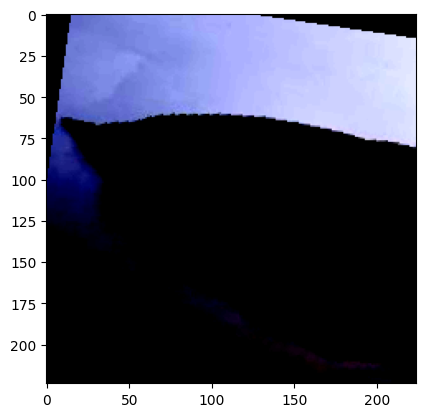

Powdery Mildew


In [6]:
#checking dataloader
import matplotlib.pyplot as plt

image,label = train_dataset[30]
plt.imshow(image.permute(1,2,0))
plt.show()
print(train_dataset.dataset.classes[label])

In [7]:
#RESNET

from torchvision.models import resnet18,ResNet18_Weights
from torch import nn,optim,device
import torch

model = resnet18(weights=ResNet18_Weights.DEFAULT)

#for training final layer

for param in model.parameters():
  param.requires_grad = False

model.fc = nn.Linear(model.fc.in_features,8)

optimizer = optim.Adam(model.fc.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

epochs = 10

def train(opt):
  best_val_acc = 0.0

  for epoch in range(epochs):

    model.train() #training

    train_loss= 0.0
    train_correct = 0.0
    train_total = 0.0
    for images, labels in train_loader:
      images = images.to(device)
      labels = labels.to(device)

      outputs = model(images)
      loss = loss_fn(outputs,labels)
      opt.zero_grad()
      loss.backward()
      opt.step()

      _,predicted = torch.max(outputs,1)
      train_correct += (predicted == labels).sum().item()
      train_total += labels.size(0)
      train_loss += loss.item()

    train_acc = 100 * train_correct / train_total
    train_loss = train_loss / len(train_loader)

    print(f"Epoch: ",epoch+1)
    print(f"Train_loss = {train_loss:.4f}")
    print(f"Train_acc = {train_acc:.2f}")


    model.eval() #validation

    val_loss = 0.0
    val_correct = 0.0
    val_total = 0.0
    with torch.no_grad():
      for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = loss_fn(outputs,labels)

        _,predicted = torch.max(outputs,1)
        val_correct += (predicted == labels).sum().item()
        val_total += labels.size(0)
        val_loss += loss.item()

    val_acc = 100* val_correct / val_total
    val_loss = val_loss / len(val_loader)

    print(f"Val_loss = {val_loss:.4f}")
    print(f"Val_accuracy = {val_acc:.2f}")

    if val_acc > best_val_acc:
      best_val_acc = val_acc
      torch.save(model.state_dict(), "best_disease_model.pth")

    print(f"Best Val Acc: {best_val_acc:.2f}")

train(optimizer)

#for fine tuning other layers

for param in model.parameters():
  param.requires_grad = True

model.load_state_dict(torch.load("best_disease_model.pth"))

optimizer_finetune = optim.Adam(model.parameters(), lr=1e-5)

train(optimizer_finetune)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 168MB/s]


Epoch:  1
Train_loss = 1.0912
Train_acc = 73.00
Val_loss = 0.5015
Val_accuracy = 88.83
Best Val Acc: 88.83
Epoch:  2
Train_loss = 0.4284
Train_acc = 93.00
Val_loss = 0.2340
Val_accuracy = 97.33
Best Val Acc: 97.33
Epoch:  3
Train_loss = 0.2755
Train_acc = 95.29
Val_loss = 0.1709
Val_accuracy = 97.67
Best Val Acc: 97.67
Epoch:  4
Train_loss = 0.2128
Train_acc = 96.64
Val_loss = 0.1244
Val_accuracy = 98.17
Best Val Acc: 98.17
Epoch:  5
Train_loss = 0.1639
Train_acc = 97.39
Val_loss = 0.1128
Val_accuracy = 97.67
Best Val Acc: 98.17
Epoch:  6
Train_loss = 0.1502
Train_acc = 97.61
Val_loss = 0.0925
Val_accuracy = 97.83
Best Val Acc: 98.17
Epoch:  7
Train_loss = 0.1310
Train_acc = 97.64
Val_loss = 0.0957
Val_accuracy = 97.17
Best Val Acc: 98.17
Epoch:  8
Train_loss = 0.1188
Train_acc = 97.46
Val_loss = 0.0714
Val_accuracy = 98.83
Best Val Acc: 98.83
Epoch:  9
Train_loss = 0.1095
Train_acc = 97.79
Val_loss = 0.0701
Val_accuracy = 98.17
Best Val Acc: 98.83
Epoch:  10
Train_loss = 0.0947
Train_

In [10]:
#TEST

model.load_state_dict(torch.load("best_disease_model.pth"))

test_loss = 0.0
test_correct = 0.0
test_total = 0.0

with torch.no_grad():
  for images , labels in test_loader:
    images = images.to(device)
    labels = labels.to(device)

    outputs = model(images)

    _,predicted = torch.max(outputs,1)

    test_correct += (predicted == labels).sum().item()
    test_total += labels.size(0)


test_acc = 100 * test_correct / test_total
test_loss = test_loss /len(test_loader)

print(f"Test loss: {test_loss:.4f}")
print(f"Test_accuracy: {test_acc:.2f}")

Test loss: 0.0000
Test_accuracy: 99.83


[[67  0  0  0  0  0  0  0]
 [ 0 72  0  0  0  0  0  0]
 [ 0  0 76  0  0  0  0  0]
 [ 0  0  0 79  0  0  0  0]
 [ 0  0  0  1 76  0  0  0]
 [ 0  0  0  0  0 67  0  0]
 [ 0  0  0  0  0  0 94  0]
 [ 0  0  0  0  0  0  0 68]]
                  precision    recall  f1-score   support

     Anthracnose       1.00      1.00      1.00        67
Bacterial Canker       1.00      1.00      1.00        72
  Cutting Weevil       1.00      1.00      1.00        76
        Die Back       0.99      1.00      0.99        79
      Gall Midge       1.00      0.99      0.99        77
         Healthy       1.00      1.00      1.00        67
  Powdery Mildew       1.00      1.00      1.00        94
     Sooty Mould       1.00      1.00      1.00        68

        accuracy                           1.00       600
       macro avg       1.00      1.00      1.00       600
    weighted avg       1.00      1.00      1.00       600



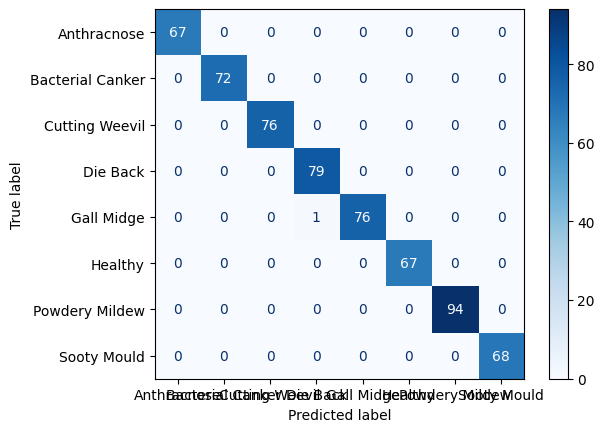

In [11]:
#Data Plotting
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = []
y_true = []

with torch.no_grad():
  for images , labels in test_loader:
    images = images.to(device)
    labels = labels.to(device)

    outputs = model(images)

    _,predicted = torch.max(outputs,1)

    y_true.extend(labels.cpu().numpy())
    y_pred.extend(predicted.cpu().numpy())


cm = confusion_matrix(y_true,y_pred)

print(cm)

print(classification_report(
    y_true,
    y_pred,
    target_names= test_dataset.dataset.classes
))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels= test_dataset.dataset.classes
)

disp.plot(cmap='Blues')
plt.show()